In [4]:
import sys
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/autoencoder/src')
from data_loader import *

sys.path.append('../..')
from python.animation import *
from python.postprocess import *
from eval import *

import sleap
sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [5]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
dataset = sleap.load_file(corrected_dataset_path)
tracked_points = get_all_tracked_points(dataset, reorder=True, interpolate=False, min_score=0, start_idx=0)

all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
reorder_idx.shape: (17,)


mean_radii: [23.82662064 25.56906133 23.13777215 23.42059619 23.63383226 25.65908751
 22.35174999 22.69927543 24.38469717 23.3873932  25.0726186  23.96431911
 22.5662053  22.09107162 25.15705849 22.90592326 20.55936431]
total_range_length: 5765
Stable ranges (frame numbers) with minimum length of 1 frames and all radii above 50.0% mean:
    - Frames 0 to 1612 (length: 1612)
    - Frames 1614 to 1728 (length: 114)
    - Frames 1730 to 1768 (length: 38)
    - Frames 1774 to 1779 (length: 5)
    - Frames 1783 to 1801 (length: 18)
    - Frames 1803 to 1843 (length: 40)
    - Frames 1850 to 1853 (length: 3)
    - Frames 1855 to 1871 (length: 16)
    - Frames 1873 to 1888 (length: 15)
    - Frames 1908 to 1991 (length: 83)
    - Frames 1993 to 2018 (length: 25)
    - Frames 2029 to 2032 (length: 3)
    - Frames 2034 to 2047 (length: 13)
    - Frames 2049 to 2064 (length: 15)
    - Frames 2066 to 2068 (length: 2)
    - Frames 2071 to 2076 (length: 5)
    - Frames 2091 to 2119 (length: 28)
   

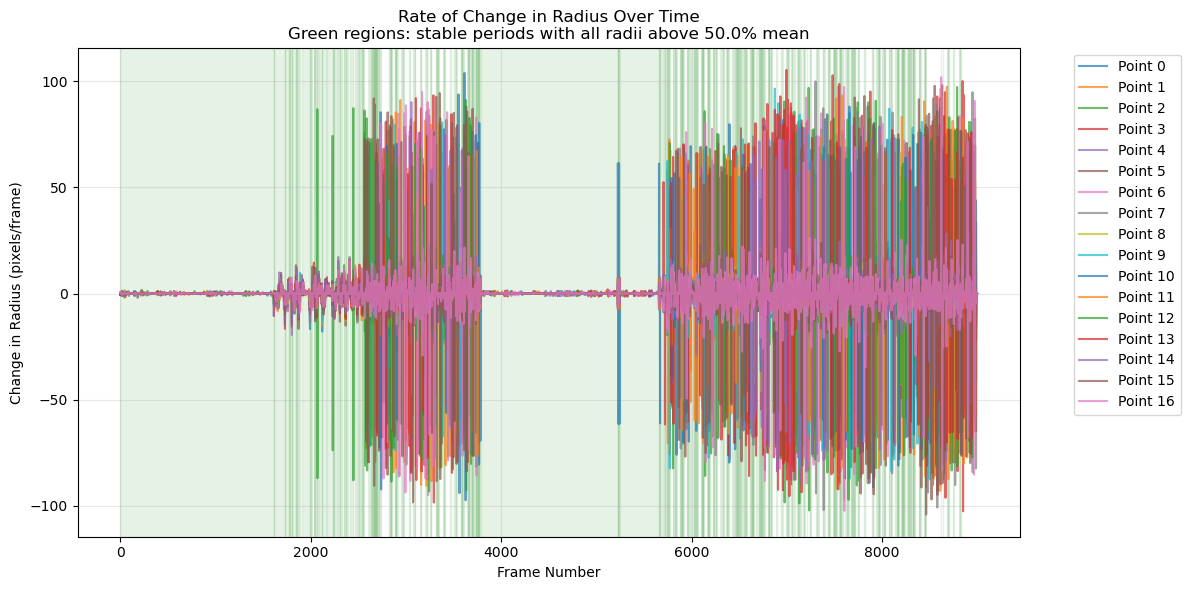

In [10]:
all_radii = get_all_radii(tracked_points)
filtered_ranges = get_expanded_periods(all_radii, 
                                        min_range_length=1, mean_scale=0.5, derivative_thres=10, 
                                        plot=True, verbose=True, use_mean=True)

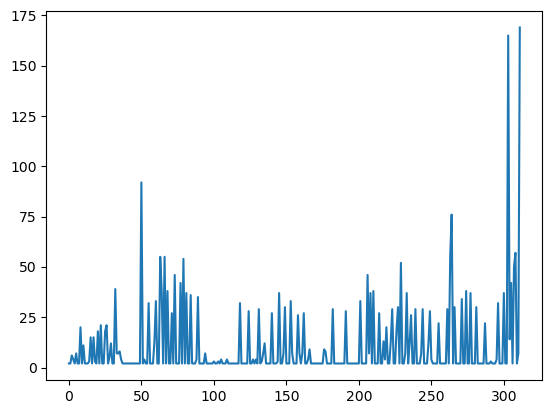

In [11]:
interval_btwn_expansions = []
for i, (start_idx, end_idx) in enumerate(filtered_ranges):
    if i == 0:
        if start_idx != 0:
            interval_btwn_expansions.append(start_idx)
    else:
        interval_btwn_expansions.append(start_idx - filtered_ranges[i-1][1])
total_frame_cnt = len(tracked_points)
if total_frame_cnt > filtered_ranges[-1][1]:
    interval_btwn_expansions.append(total_frame_cnt - filtered_ranges[-1][1])
    
plt.plot(interval_btwn_expansions)
plt.show()

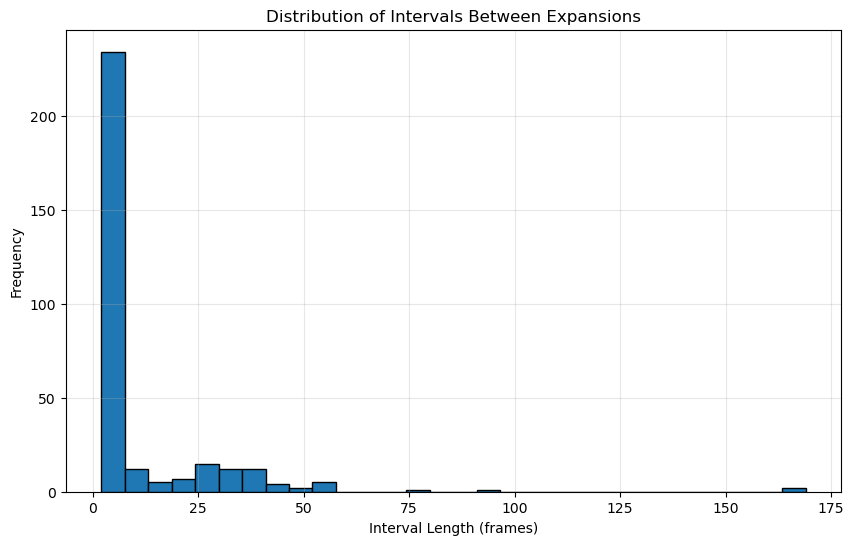

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(interval_btwn_expansions, bins=30, edgecolor='black')
plt.xlabel('Interval Length (frames)')
plt.ylabel('Frequency')
plt.title('Distribution of Intervals Between Expansions')
plt.grid(True, alpha=0.3)
plt.show()